# 🔧 Step 2 — Feature Engineering & Correlation Analysis

> **Goal:** Transform raw variables into model-ready features, build composite indices,
> create interaction terms, and rigorously measure their linear relationship with the target.

---
### Why engineer features?
GDP growth rate is a signed, bounded percentage — very different from a GDP level. Population still has large scale and skew. Linear regression assumes approximate normality and constant variance. We apply a **signed log transform** to GDP growth (preserving recession direction) and standard log1p to population. This dramatically improves coefficient interpretability.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#c8ccd8',
    'axes.titlecolor': '#e8eaf0', 'xtick.color': '#8890a8',
    'ytick.color': '#8890a8', 'grid.color': '#2e3347',
    'grid.linewidth': 0.6, 'text.color': '#e8eaf0',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'figure.dpi': 130,
})

ACCENT  = '#4fc3f7'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#a5d6a7'
ACCENT4 = '#ffb74d'
GRAD    = ['#4fc3f7','#7986cb','#ff6b6b','#ffb74d','#a5d6a7','#f48fb1','#80cbc4','#ce93d8']

df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Terrorism_gdp_growth\df_clean.csv")
print(f'Loaded: {df.shape}')

Loaded: (2742, 17)


## 2.1 Log-transformations for skewed predictors

Population spans many orders of magnitude across countries — standard `log1p` applies.

GDP here is a **growth rate (%)**, not a level. It is already on a small, signed scale and can be negative (recessions). We apply a **signed log transform**: `sign(gdp) × log(1 + |gdp|)`. This:
- Compresses large positive growth values symmetrically
- Preserves the sign of contractions (negative stays negative)
- Is safe for zero and any negative input

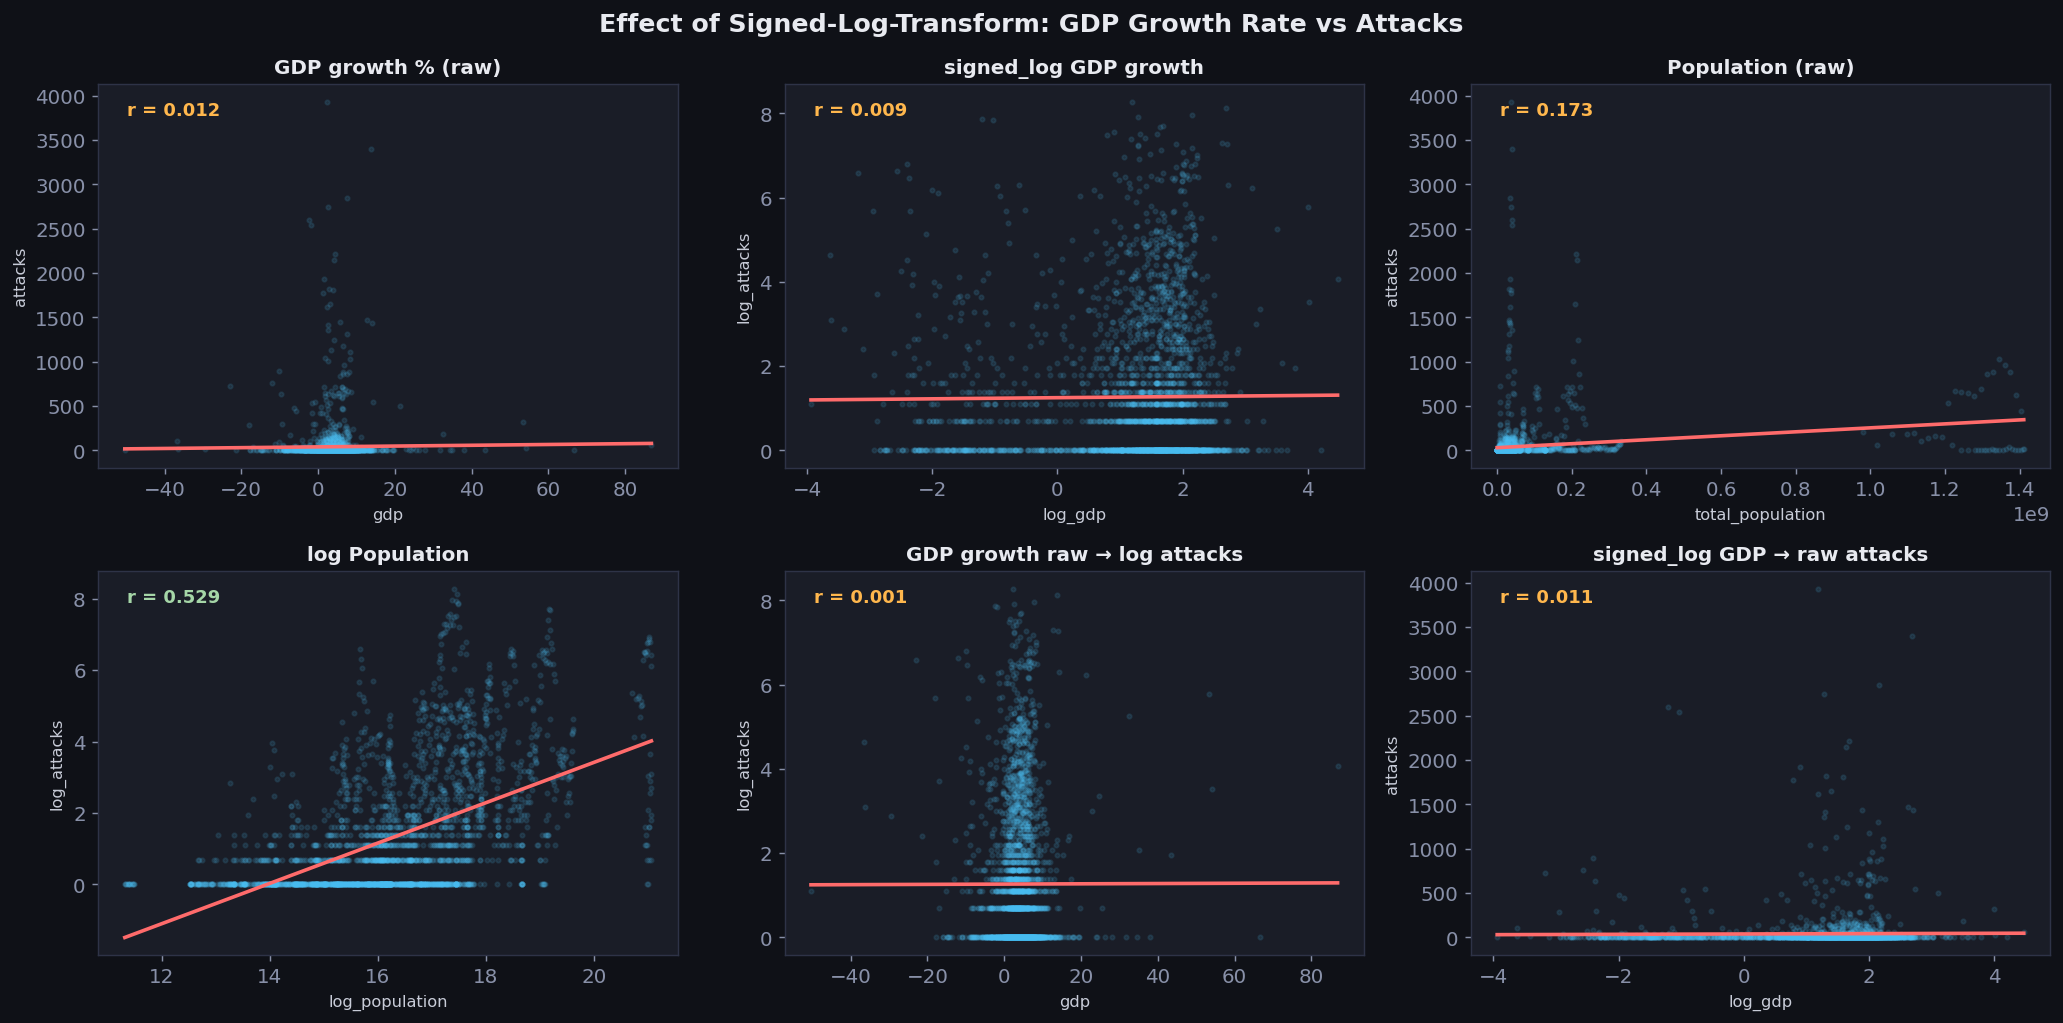

Best correlation pair: signed_log_gdp → log_attacks r = 0.009


In [2]:
# Signed log transform — safe for negative GDP growth (recessions)
df['log_gdp']        = np.sign(df['gdp']) * np.log1p(np.abs(df['gdp']))
df['log_population'] = np.log1p(df['total_population'])
df['log_attacks']    = np.log1p(df['attacks'])

# Show the before / after for GDP
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

pairs = [
    ('gdp',              'attacks',      'GDP growth % (raw)'),
    ('log_gdp',          'log_attacks',  'signed_log GDP growth'),
    ('total_population', 'attacks',      'Population (raw)'),
    ('log_population',   'log_attacks',  'log Population'),
    ('gdp',              'log_attacks',  'GDP growth raw → log attacks'),
    ('log_gdp',          'attacks',      'signed_log GDP → raw attacks'),
]

for ax, (xcol, ycol, title) in zip(axes.flat, pairs):
    valid = df[[xcol, ycol]].dropna()
    ax.scatter(valid[xcol], valid[ycol], alpha=0.12, s=6, color=ACCENT)
    m, b, r, p, _ = stats.linregress(valid[xcol], valid[ycol])
    xs = np.linspace(valid[xcol].min(), valid[xcol].max(), 200)
    ax.plot(xs, m*xs + b, color=ACCENT2, lw=2)
    color = ACCENT3 if abs(r) > 0.3 else ACCENT4
    ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
            fontsize=10, color=color, fontweight='bold')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xcol, fontsize=9)
    ax.set_ylabel(ycol, fontsize=9)

fig.suptitle('Effect of Signed-Log-Transform: GDP Growth Rate vs Attacks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Best correlation pair: signed_log_gdp → log_attacks',
      f"r = {df[['log_gdp','log_attacks']].corr().iloc[0,1]:.3f}")

## 2.2 Governance composite index

Five World Governance Indicators (WGI) measure related aspects of state capacity. 
Rather than include them all separately (risking multicollinearity), we create a 
**governance composite** as their mean. This is standard in conflict-studies literature.

We do not use PCA because the World Governance Indicators are conceptually designed to measure a common latent construct (state capacity) and exhibit high mutual correlation. A simple average therefore provides a stable, interpretable, and theory-consistent composite. PCA would introduce data-dependent weights, reduce interpretability, and offer minimal additional explanatory power in this setting.

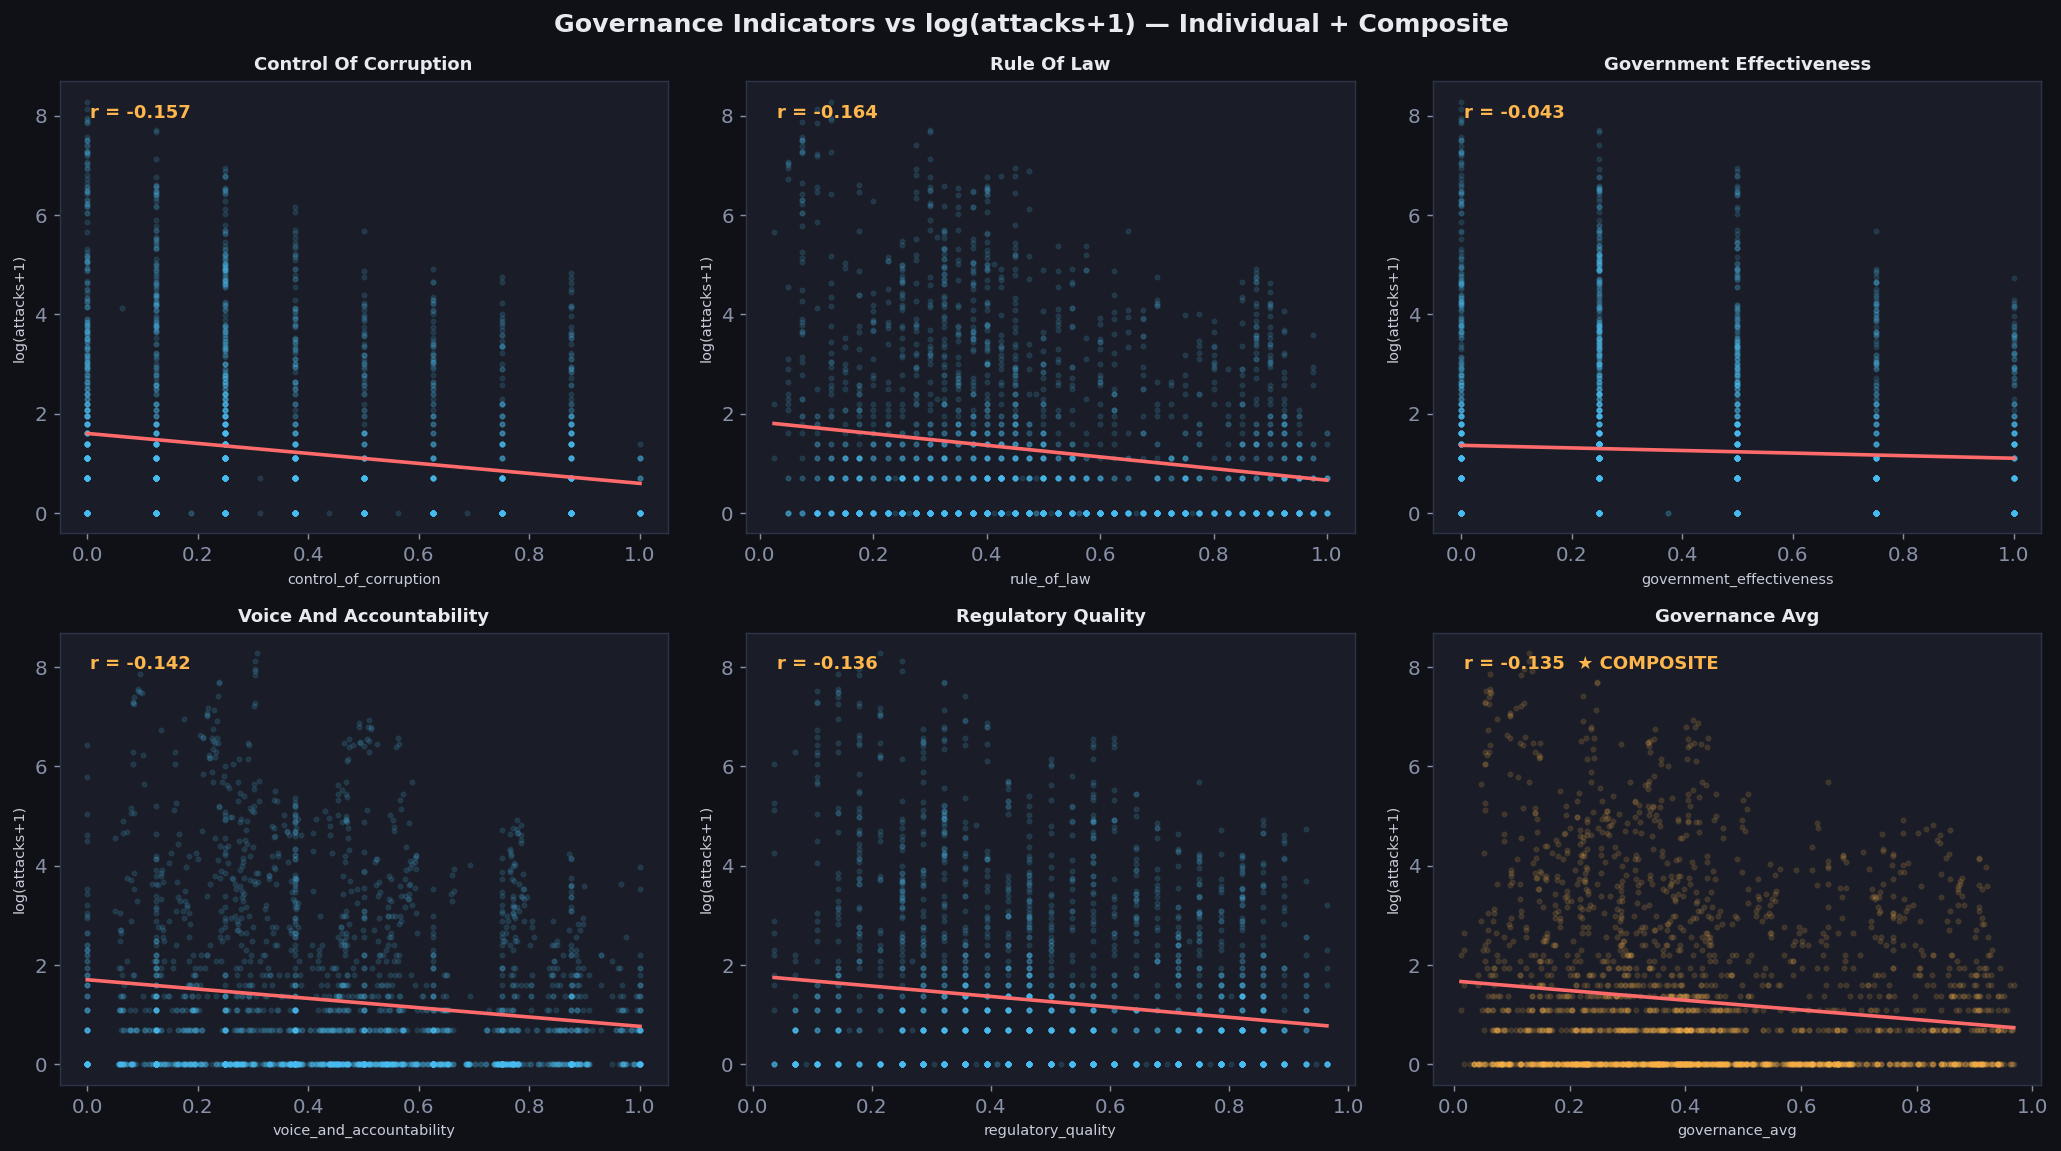

In [3]:
gov_cols = ['control_of_corruption', 'rule_of_law', 'government_effectiveness',
            'voice_and_accountability', 'regulatory_quality']

df['governance_avg'] = df[gov_cols].mean(axis=1)

# Visualise the 5 components + composite
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, gov_cols + ['governance_avg']):
    valid = df[[col, 'log_attacks']].dropna()
    ax.scatter(valid[col], valid['log_attacks'],
               alpha=0.12, s=6, color=ACCENT4 if col == 'governance_avg' else ACCENT)
    m, b, r, p, _ = stats.linregress(valid[col], valid['log_attacks'])
    xs = np.linspace(valid[col].min(), valid[col].max(), 200)
    ax.plot(xs, m*xs + b, color=ACCENT2, lw=2)
    lbl = '★ COMPOSITE' if col == 'governance_avg' else ''
    ax.text(0.05, 0.92, f'r = {r:.3f}  {lbl}', transform=ax.transAxes,
            fontsize=10, color=ACCENT3 if abs(r) > 0.3 else ACCENT4, fontweight='bold')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('log(attacks+1)', fontsize=8)

fig.suptitle('Governance Indicators vs log(attacks+1) — Individual + Composite',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.3 Interaction term: `stress_x_weak`

**Theory:** High poverty *combined with* weak governance creates the conditions for 
conflict to emerge. Neither factor alone is sufficient — it is their joint presence 
that matters. We capture this with a multiplicative interaction:

$$\text{stress\_x\_weak} = \text{poverty\_headcount} \times (1 - \text{governance\_avg})$$

This interaction explicitly encodes the idea that conflict risk emerges from the combination of economic stress and weak institutions—not from either factor alone.

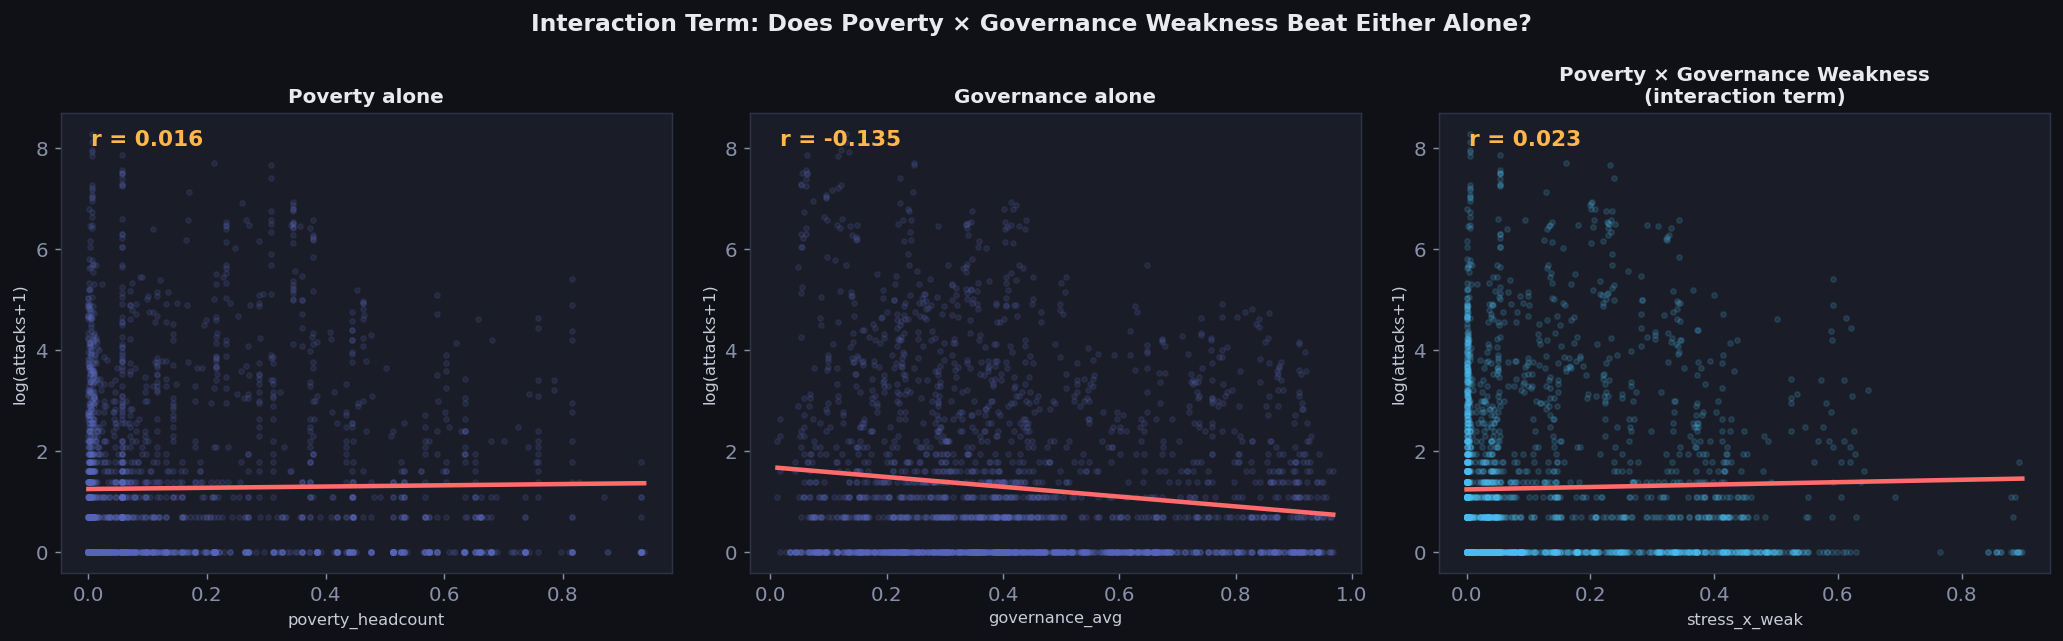

In [4]:
df['stress_x_weak'] = df['poverty_headcount'] * (1 - df['governance_avg'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (xcol, title) in zip(axes, [
    ('poverty_headcount', 'Poverty alone'),
    ('governance_avg',    'Governance alone'),
    ('stress_x_weak',     'Poverty × Governance Weakness\n(interaction term)'),
]):
    valid = df[[xcol, 'log_attacks']].dropna()
    ax.scatter(valid[xcol], valid['log_attacks'],
               alpha=0.14, s=8, color=ACCENT if xcol == 'stress_x_weak' else '#5c6bc0')
    m, b, r, p, _ = stats.linregress(valid[xcol], valid['log_attacks'])
    xs = np.linspace(valid[xcol].min(), valid[xcol].max(), 200)
    ax.plot(xs, m*xs + b, color=ACCENT2, lw=2.5)
    ax.text(0.05, 0.93, f'r = {r:.3f}', transform=ax.transAxes,
            fontsize=12, color=ACCENT3 if abs(r) > 0.3 else ACCENT4, fontweight='bold')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xcol, fontsize=9)
    ax.set_ylabel('log(attacks+1)', fontsize=9)

fig.suptitle('Interaction Term: Does Poverty × Governance Weakness Beat Either Alone?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.4 Final feature set summary

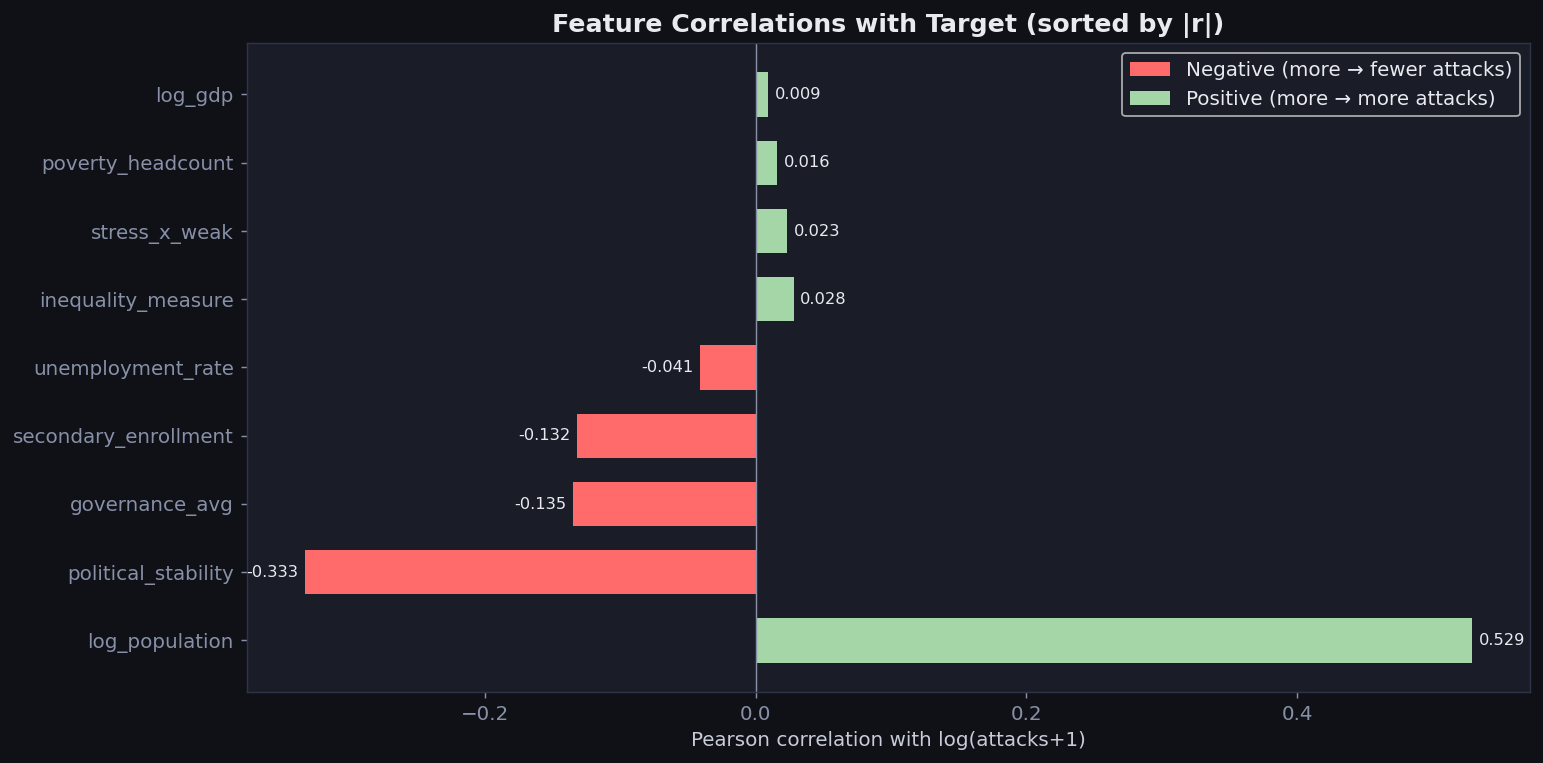

             Feature       Type  Pearson r  Spearman r Expected sign
      log_population Engineered      0.529       0.547             +
 political_stability        Raw     -0.333      -0.295             -
      governance_avg Engineered     -0.135      -0.107             -
secondary_enrollment        Raw     -0.132      -0.084             -
   unemployment_rate        Raw     -0.041      -0.021             -
  inequality_measure        Raw      0.028      -0.016             +
       stress_x_weak Engineered      0.023       0.043             +
   poverty_headcount        Raw      0.016       0.033             +
             log_gdp Engineered      0.009      -0.014             +


In [5]:
FINAL_FEATS = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]

feat_summary = []
for col in FINAL_FEATS:
    r_val, _ = pearsonr(df[col].dropna(), df.loc[df[col].notna(), 'log_attacks'])
    sr_val, _ = spearmanr(df[col].dropna(), df.loc[df[col].notna(), 'log_attacks'])
    feat_summary.append({
        'Feature': col,
        'Type': 'Engineered' if col in ['log_gdp','log_population','governance_avg','stress_x_weak'] else 'Raw',
        'Pearson r': round(r_val, 3),
        'Spearman r': round(sr_val, 3),
        'Expected sign': '-' if r_val < 0 else '+',
    })

feat_df = pd.DataFrame(feat_summary).sort_values('Pearson r', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [ACCENT2 if v < 0 else ACCENT3 for v in feat_df['Pearson r']]
bars = ax.barh(feat_df['Feature'], feat_df['Pearson r'],
               color=colors, edgecolor='none', height=0.65)
for bar, val in zip(bars, feat_df['Pearson r']):
    xpos = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9, color='#e8eaf0')
ax.axvline(0, color='#8890a8', lw=0.8)
ax.set_xlabel('Pearson correlation with log(attacks+1)')
ax.set_title('Feature Correlations with Target (sorted by |r|)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=ACCENT2, label='Negative (more → fewer attacks)'),
                   Patch(facecolor=ACCENT3, label='Positive (more → more attacks)')],
          loc='best')
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))


log_population (r = 0.529)
Strongest predictor; larger populations are associated with more attacks, reflecting a scaling/exposure effect rather than direct causation.

political_stability (r = -0.333)
Clear and meaningful negative relationship; more stability significantly reduces attacks, making it the most important institutional factor.

governance_avg (r = -0.135)
Moderate negative effect; better overall governance lowers attacks, though its influence is weaker than political stability.

secondary_enrollment (r = -0.132)
Education is associated with fewer attacks, suggesting long-term socio-economic development reduces conflict risk.

unemployment_rate (r = -0.041)
Very weak and slightly negative; no reliable linear relationship, likely noisy or context-dependent.

inequality_measure (r = 0.028)
Near-zero correlation; inequality alone does not explain attacks linearly and likely acts through nonlinear or interaction effects.

stress_x_weak (r = 0.023)
Weak marginal correlation, but theoretically important; captures combined effect of poverty and weak governance, which simple correlation cannot detect.

poverty_headcount (r = 0.016)
Almost no standalone effect; supports the idea that poverty alone is insufficient to drive conflict without institutional weakness.

log_gdp (r = 0.014)
No meaningful relationship; GDP does not directly explain attacks in this dataset and is likely irrelevant in linear form.

## 2.5 Full correlation heatmap — detecting multicollinearity

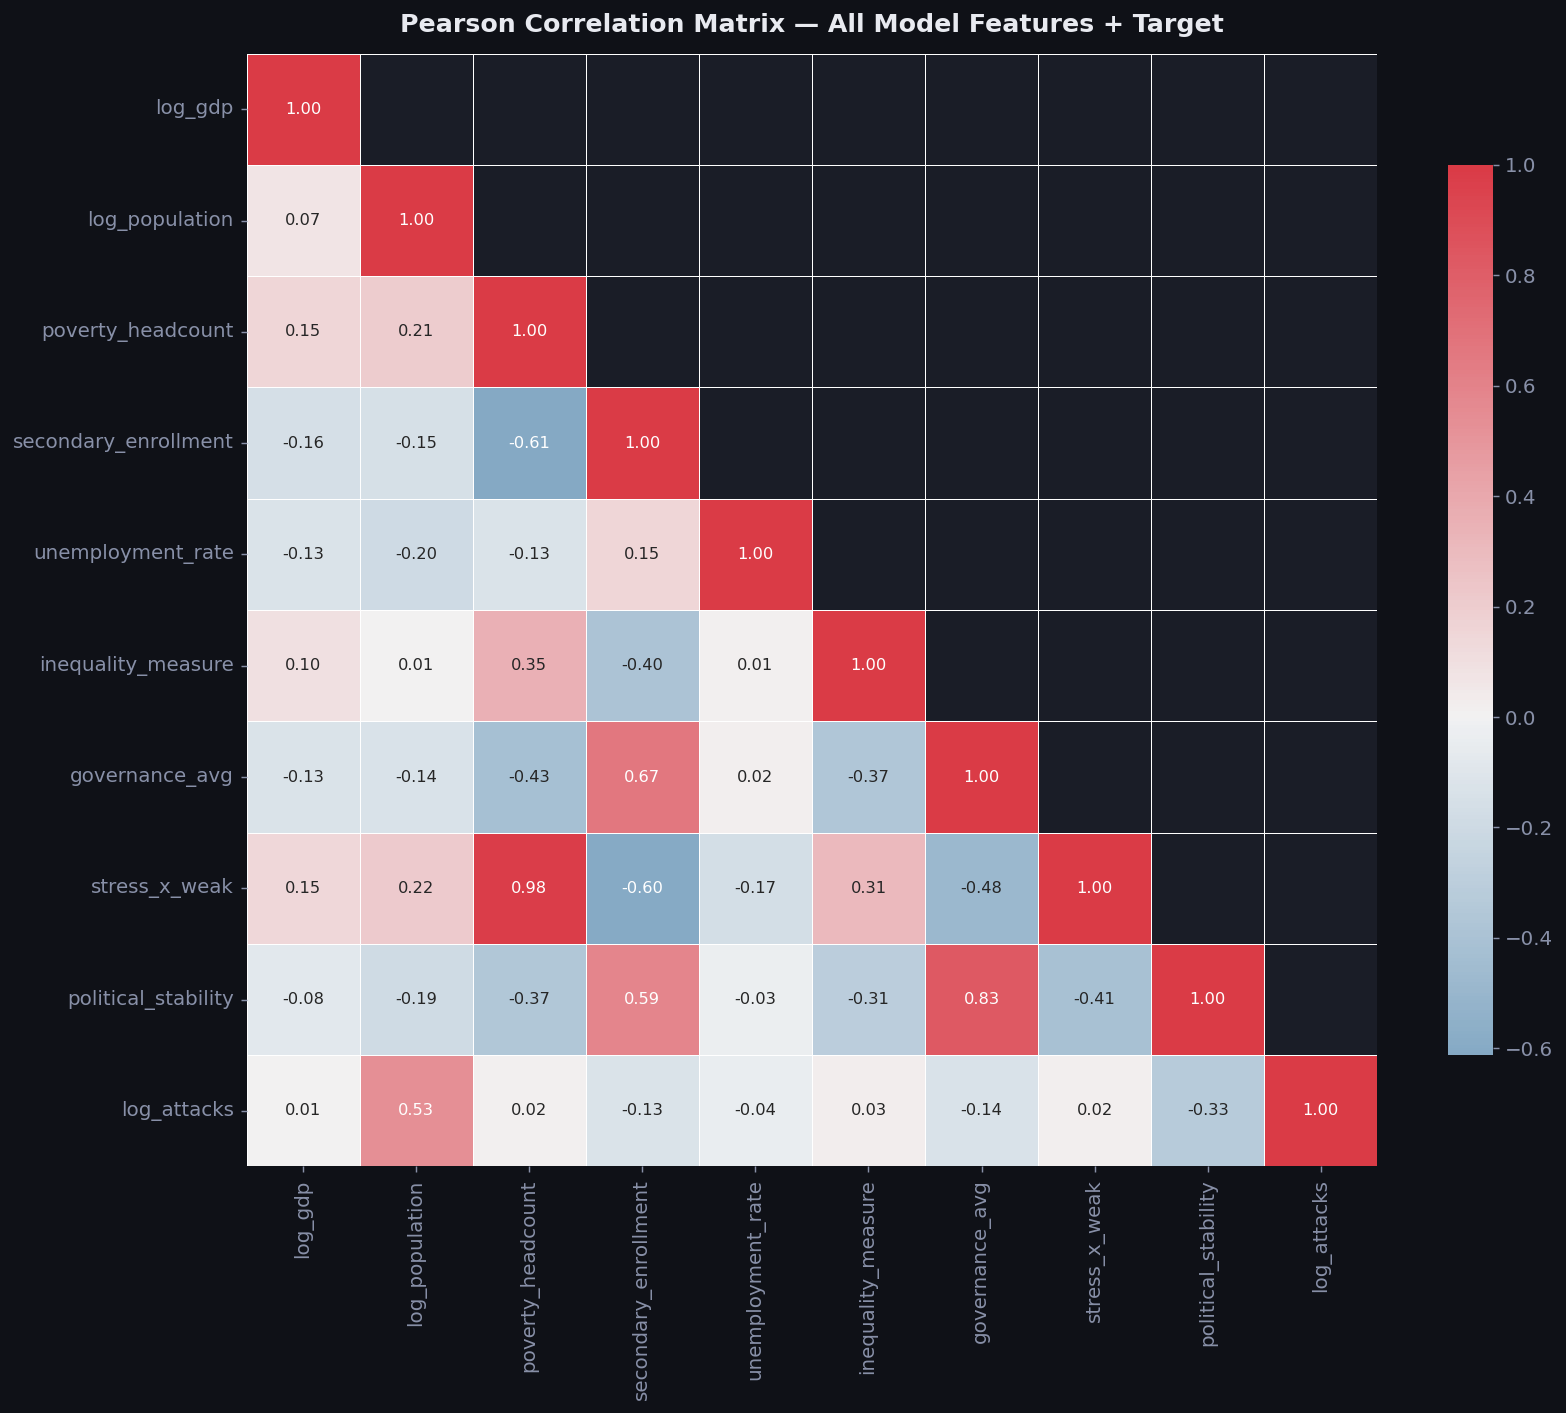


Pairs with |r| > 0.7 (potential multicollinearity):
  stress_x_weak                   ↔  poverty_headcount               r = 0.981
  political_stability             ↔  governance_avg                  r = 0.828


In [6]:
all_cols = FINAL_FEATS + ['log_attacks']
corr_mat = df[all_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)

cmap = sns.diverging_palette(240, 10, as_cmap=True)   # blue–red
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap=cmap, center=0, linewidths=.5, ax=ax,
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})

ax.set_title('Pearson Correlation Matrix — All Model Features + Target', pad=12)
plt.tight_layout()
plt.show()

# Highlight high inter-predictor correlations (potential multicollinearity)
print('\nPairs with |r| > 0.7 (potential multicollinearity):')
high = (corr_mat.abs() > 0.7) & (corr_mat.abs() < 1.0)
found = [(corr_mat.index[i], corr_mat.columns[j], round(corr_mat.iloc[i,j], 3))
         for i in range(len(corr_mat)) for j in range(i)
         if high.iloc[i,j]]
for a, b, r in found:
    print(f'  {a:30s}  ↔  {b:30s}  r = {r}')

Population scaling effect (r ≈ 0.53): The strong positive association between log_population and log_attacks indicates a size/exposure-driven process, consistent with a log–log (power-law–type) relationship, where larger populations systematically generate more events.

Political stability as core determinant (r ≈ -0.33): The largest substantive negative correlation suggests institutional stability is the primary explanatory factor reducing conflict incidence, aligning with state-capacity theories.

Severe multicollinearity (governance ↔ stability, r ≈ 0.83): These variables capture a common latent construct (institutional quality), implying redundancy and potential instability in coefficient estimates if included jointly without regularization.

Interaction term degeneracy (stress_x_weak ↔ poverty, r ≈ 0.98): The interaction is nearly collinear with poverty, indicating poor construction (lack of orthogonality), thus failing to capture a distinct conditional effect.

Development structure (poverty ↔ education, r ≈ -0.61): Strong negative correlation reflects a structural socio-economic gradient, validating internal consistency of development indicators.

Education–institution nexus (education ↔ governance, r ≈ 0.67; ↔ stability, r ≈ 0.59): Suggests human capital and institutional quality co-evolve, raising concerns about overlapping explanatory pathways.

GDP irrelevance (≈ 0 correlations): Lack of association with both target and key predictors implies GDP level is not a meaningful driver in this conflict context, possibly due to aggregation bias or opposing effects.

Inequality as weak independent dimension: Low correlations across variables indicate it captures a distinct but weakly predictive structural factor, potentially requiring nonlinear modeling.

Unemployment insignificance: Near-zero correlations suggest limited explanatory power in a cross-sectional linear framework, possibly due to measurement noise or lagged/indirect effects.

## 2.6 Save enriched dataset

In [7]:
df.to_csv('df_features.csv', index=False)

print('New features added:')
print('  log_gdp        : sign(gdp) * log(1 + |gdp|)  ← signed log of GDP growth rate')
print('  log_population : log(1 + total_population)')
print('  governance_avg : mean of 5 WGI indicators')
print('  stress_x_weak  : poverty_headcount × (1 - governance_avg)')
print('  log_attacks    : log(1 + attacks)  ← target for regression')
print(f'\nFinal shape: {df.shape}')
print('Ready for Step 3 ✓')

New features added:
  log_gdp        : sign(gdp) * log(1 + |gdp|)  ← signed log of GDP growth rate
  log_population : log(1 + total_population)
  governance_avg : mean of 5 WGI indicators
  stress_x_weak  : poverty_headcount × (1 - governance_avg)
  log_attacks    : log(1 + attacks)  ← target for regression

Final shape: (2742, 21)
Ready for Step 3 ✓
